In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import statsmodels.api as sm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [55]:
end = dt.date.today()
start = end - dt.timedelta(365*10)
df = yf.download(["RELIANCE.NS", "ONGC.NS"], start=start, end=end, auto_adjust=True)

[*********************100%***********************]  2 of 2 completed


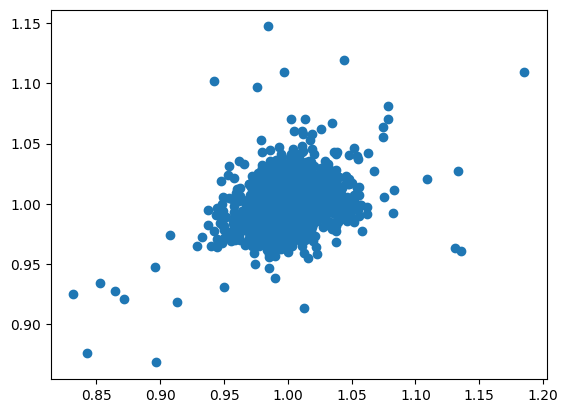

In [56]:
# Cleaning
df.columns = df.columns.droplevel(1)
df.columns = df.columns.str.lower()
df.drop(columns=["high",'low','open','volume'], inplace=True)
df.columns = ["ongc", "rel"]
#Returns
df['ongc_returns'] = df['ongc'] / df['ongc'].shift(1)
df['rel_returns'] = df['rel'] / df['rel'].shift(1)
df.dropna(inplace=True)
# Plotting
x = df['ongc_returns']
y = df['rel_returns']
plt.scatter(x,y)